# CRNN (Convolutional Recurrent Neural Network) Training for PTM Prediction

This notebook trains a hybrid CRNN model that combines convolutional and recurrent layers with attention for multi-label classification of protein PTMs.

## Architecture: Conv1D + BiGRU + Attention

```
Input (31 amino acids)
  ↓
Embedding(vocab=21, dim=64)
  ↓
Conv1D(128) + BatchNorm + ReLU + Dropout  # Local patterns
  ↓
Conv1D(256) + BatchNorm + ReLU + Dropout
  ↓
MaxPooling1D(pool_size=2)
  ↓
Bidirectional GRU(128, return_sequences=True)  # Sequential dependencies
  ↓
Bidirectional GRU(64, return_sequences=True)
  ↓
Attention Layer  # Focus on important positions
  ↓
Dense(128) + BatchNorm + ReLU + Dropout
  ↓
Dense(64) + BatchNorm + ReLU + Dropout
  ↓
Dense(3, activation='sigmoid')  # Multi-label output
```

## Key Differences from CNN (06a):
- **CNN**: Embedding → Conv1D → GlobalMaxPooling → Dense
- **CRNN** (this): Embedding → Conv1D → BiGRU → Attention → Dense

**Why CRNN?**
- Captures **local motifs** (Conv1D) AND **sequential dependencies** (BiGRU)
- Attention focuses on **important sequence positions**
- Expected improvement: +10-15% F1 over pure CNN

## Labels to Predict:
1. S-glutathionylation (very rare: ~5% positive)
2. S-nitrosylation (rare: ~12% positive)
3. S-palmitoylation (very rare: ~3% positive)

## 1. Configuration

In [1]:
# ============================================================================
# CONFIGURATION PARAMETERS
# ============================================================================

# Experiment name
EXPERIMENT_NAME = "run01_baseline"

# Sequence parameters
SEQ_LENGTH = 31
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
VOCAB_SIZE = 21  # 20 amino acids + 1 for padding

# Architecture hyperparameters
EMBEDDING_DIM = 64
CONV_FILTERS = [128, 256]
KERNEL_SIZES = [3, 3]
POOL_SIZE = 2
GRU_UNITS = [128, 64]  # Two stacked GRU layers
USE_BIDIRECTIONAL = True
DROPOUT_CONV = 0.2
DROPOUT_RECURRENT = 0.2
DROPOUT_DENSE = 0.3
DENSE_UNITS = [128, 64]

# Training hyperparameters
BATCH_SIZE = 128
EPOCHS = 50
LEARNING_RATE = 0.001
EARLY_STOPPING_PATIENCE = 10
USE_CLASS_WEIGHTS = True
DAMPEN_FACTOR = 0.5  # Dampen class weights (same as CNN)

# System
N_CORES = 16
RANDOM_STATE = 42

# File paths
TRAIN_FILE = "../data_engineered/onehot/train_with_features_onehot_split.csv"
VAL_FILE = "../data_engineered/onehot/val_with_features_onehot_split.csv"
OUTPUT_DIR = f"../output/crnn/{EXPERIMENT_NAME}"

print("Configuration:")
print(f"  Experiment: {EXPERIMENT_NAME}")
print(f"  Sequence length: {SEQ_LENGTH}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Conv filters: {CONV_FILTERS}")
print(f"  GRU units: {GRU_UNITS}")
print(f"  Bidirectional: {USE_BIDIRECTIONAL}")

Configuration:
  Experiment: run01_baseline
  Sequence length: 31
  Batch size: 128
  Epochs: 50
  Conv filters: [128, 256]
  GRU units: [128, 64]
  Bidirectional: True


## 2. Set CPU Usage

In [2]:
import os

# Set number of threads BEFORE importing TensorFlow
os.environ['TF_NUM_INTRAOP_THREADS'] = str(N_CORES)
os.environ['TF_NUM_INTEROP_THREADS'] = str(N_CORES)
os.environ['OMP_NUM_THREADS'] = str(N_CORES)
os.environ['MKL_NUM_THREADS'] = str(N_CORES)

## 3. Import Libraries

In [3]:
# Standard libraries
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Sklearn
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score,
    hamming_loss
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set TensorFlow threads
tf.config.threading.set_intra_op_parallelism_threads(N_CORES)
tf.config.threading.set_inter_op_parallelism_threads(N_CORES)

# Set random seeds
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"✓ TensorFlow version: {tf.__version__}")
print(f"✓ Keras version: {keras.__version__}")
print(f"✓ Using {N_CORES} CPU threads")

2025-12-05 17:18:23.988656: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-05 17:18:24.029883: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ TensorFlow version: 2.19.1
✓ Keras version: 3.11.2
✓ Using 16 CPU threads


## 4. Load Data

In [4]:
# Load train and validation data
print("Loading data...")
train_df = pd.read_csv(TRAIN_FILE)
val_df = pd.read_csv(VAL_FILE)

print(f"✓ Training samples: {len(train_df):,}")
print(f"✓ Validation samples: {len(val_df):,}")

# Extract sequences and labels
X_train_seq = train_df['Sequence'].values
X_val_seq = val_df['Sequence'].values

label_cols = ['S-glutathionylation', 'S-nitrosylation', 'S-palmitoylation']
y_train = train_df[label_cols].values.astype(float)
y_val = val_df[label_cols].values.astype(float)

print(f"\nLabel distribution in training set:")
for i, label in enumerate(label_cols):
    pos_count = y_train[:, i].sum()
    pos_pct = pos_count / len(y_train) * 100
    print(f"  {label}: {int(pos_count):,} ({pos_pct:.2f}%)")

# Show sample sequences
print(f"\nSample sequences:")
for i in range(3):
    print(f"  {X_train_seq[i]} -> {y_train[i]}")

Loading data...
✓ Training samples: 71,208
✓ Validation samples: 17,802

Label distribution in training set:
  S-glutathionylation: 3,786 (5.32%)
  S-nitrosylation: 8,845 (12.42%)
  S-palmitoylation: 2,662 (3.74%)

Sample sequences:
  ANCPLSCPANSRYELCGPACPTSCNGAAAPS -> [0. 0. 0.]
  PNPDFQLLLSLREELCKKLNIPADQVELSMG -> [0. 0. 0.]
  VSDYDPTIEDSYTKICTVDGIPARLDILDTA -> [0. 1. 1.]


## 5. Sequence Encoding

Convert amino acid sequences to integer indices.

In [5]:
# Create amino acid to integer mapping
aa_to_int = {aa: i+1 for i, aa in enumerate(AMINO_ACIDS)}  # Start from 1, reserve 0 for padding
aa_to_int['X'] = 0  # Unknown amino acid

print("Amino acid to integer mapping:")
print(aa_to_int)

def encode_sequence(sequence, max_length=SEQ_LENGTH):
    """
    Convert amino acid sequence to integer encoding.
    Pads or truncates to max_length.
    """
    encoded = [aa_to_int.get(aa, 0) for aa in sequence[:max_length]]
    
    # Pad if necessary
    if len(encoded) < max_length:
        encoded += [0] * (max_length - len(encoded))
    
    return encoded

# Encode all sequences
print("\nEncoding sequences...")
X_train = np.array([encode_sequence(seq) for seq in X_train_seq])
X_val = np.array([encode_sequence(seq) for seq in X_val_seq])

print(f"✓ Encoded training shape: {X_train.shape}")
print(f"✓ Encoded validation shape: {X_val.shape}")

# Save mapping for future use
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
with open(f"{OUTPUT_DIR}/aa_to_int.pkl", 'wb') as f:
    pickle.dump(aa_to_int, f)
print(f"✓ Saved mapping to {OUTPUT_DIR}/aa_to_int.pkl")

Amino acid to integer mapping:
{'A': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10, 'M': 11, 'N': 12, 'P': 13, 'Q': 14, 'R': 15, 'S': 16, 'T': 17, 'V': 18, 'W': 19, 'Y': 20, 'X': 0}

Encoding sequences...
✓ Encoded training shape: (71208, 31)
✓ Encoded validation shape: (17802, 31)
✓ Saved mapping to ../output/crnn/run01_baseline/aa_to_int.pkl


## 6. Calculate Class Weights

Handle severe class imbalance using dampened weights.

In [6]:
def calculate_class_weights(y, dampen_factor=DAMPEN_FACTOR):
    """
    Calculate dampened class weights for each label.
    
    For each sample, weight = (1 if negative, pos_weight if positive)
    pos_weight = (neg_count / pos_count) * dampen_factor
    """
    sample_weights = np.ones((len(y), y.shape[1]))
    
    for i in range(y.shape[1]):
        pos_count = y[:, i].sum()
        neg_count = len(y) - pos_count
        
        if pos_count > 0:
            pos_weight = (neg_count / pos_count) * dampen_factor
            sample_weights[:, i] = np.where(y[:, i] == 1, pos_weight, 1.0)
    
    # Average across labels for multi-label
    sample_weights = sample_weights.mean(axis=1)
    
    return sample_weights

if USE_CLASS_WEIGHTS:
    print("Calculating class weights...")
    train_sample_weights = calculate_class_weights(y_train, DAMPEN_FACTOR)
    
    print(f"✓ Sample weights calculated")
    print(f"  Min weight: {train_sample_weights.min():.3f}")
    print(f"  Max weight: {train_sample_weights.max():.3f}")
    print(f"  Mean weight: {train_sample_weights.mean():.3f}")
else:
    train_sample_weights = None
    print("Not using class weights")

Calculating class weights...
✓ Sample weights calculated
  Min weight: 1.000
  Max weight: 8.435
  Mean weight: 1.393


## 7. Custom Attention Layer

Attention mechanism to focus on important sequence positions.

In [7]:
class AttentionLayer(layers.Layer):
    """
    Attention mechanism for sequence data.
    Learns which positions in the sequence are most important for prediction.
    
    Based on: https://arxiv.org/abs/1409.0473
    """
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    
    def build(self, input_shape):
        # input_shape: (batch, time_steps, features)
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], input_shape[-1]),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="attention_bias",
            shape=(input_shape[-1],),
            initializer="zeros",
            trainable=True
        )
        self.u = self.add_weight(
            name="attention_context",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)
    
    def call(self, inputs):
        # inputs: (batch, time_steps, features)
        
        # Compute attention scores
        # e_t = tanh(W * h_t + b)
        e = tf.nn.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        
        # alpha_t = softmax(u^T * e_t)
        scores = tf.tensordot(e, self.u, axes=1)  # (batch, time_steps, 1)
        attention_weights = tf.nn.softmax(scores, axis=1)
        
        # Context vector: weighted sum of hidden states
        context = tf.reduce_sum(inputs * attention_weights, axis=1)
        
        return context
    
    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])
    
    def get_config(self):
        return super(AttentionLayer, self).get_config()

print("✓ Attention layer defined")

✓ Attention layer defined


## 8. Build CRNN Model

Construct the full CRNN architecture.

In [8]:
def build_crnn_model(
    vocab_size,
    seq_length,
    embedding_dim,
    conv_filters,
    kernel_sizes,
    pool_size,
    gru_units,
    use_bidirectional,
    dropout_conv,
    dropout_recurrent,
    dropout_dense,
    dense_units,
    num_labels
):
    """
    Build CRNN model with Conv1D + BiGRU + Attention.
    
    Returns:
        Keras model
    """
    # Input
    inputs = layers.Input(shape=(seq_length,), name="sequence_input")
    
    # Embedding layer
    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=seq_length,
        name="embedding"
    )(inputs)
    
    # Convolutional blocks (local pattern extraction)
    for i, (filters, kernel_size) in enumerate(zip(conv_filters, kernel_sizes)):
        x = layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            padding='same',
            name=f"conv1d_{i+1}"
        )(x)
        x = layers.BatchNormalization(name=f"bn_conv_{i+1}")(x)
        x = layers.Activation('relu', name=f"relu_conv_{i+1}")(x)
        x = layers.Dropout(dropout_conv, name=f"dropout_conv_{i+1}")(x)
    
    # Max pooling (reduce sequence length)
    x = layers.MaxPooling1D(pool_size=pool_size, name="max_pooling")(x)
    
    # Stacked Bidirectional GRU layers (sequential dependencies)
    for i, units in enumerate(gru_units):
        return_sequences = (i < len(gru_units) - 1) or True  # Always return sequences for attention
        
        gru = layers.GRU(
            units=units,
            return_sequences=return_sequences,
            dropout=dropout_recurrent,
            recurrent_dropout=dropout_recurrent,
            name=f"gru_{i+1}"
        )
        
        if use_bidirectional:
            x = layers.Bidirectional(gru, name=f"bi_gru_{i+1}")(x)
        else:
            x = gru(x)
    
    # Attention layer (focus on important positions)
    x = AttentionLayer(name="attention")(x)
    
    # Dropout after attention
    x = layers.Dropout(dropout_dense, name="dropout_attention")(x)
    
    # Dense layers
    for i, units in enumerate(dense_units):
        x = layers.Dense(units, name=f"dense_{i+1}")(x)
        x = layers.BatchNormalization(name=f"bn_dense_{i+1}")(x)
        x = layers.Activation('relu', name=f"relu_dense_{i+1}")(x)
        x = layers.Dropout(dropout_dense, name=f"dropout_dense_{i+1}")(x)
    
    # Output layer (multi-label classification)
    outputs = layers.Dense(num_labels, activation='sigmoid', name="output")(x)
    
    # Build model
    model = models.Model(inputs=inputs, outputs=outputs, name="CRNN")
    
    return model

# Build the model
print("Building CRNN model...")
model = build_crnn_model(
    vocab_size=VOCAB_SIZE,
    seq_length=SEQ_LENGTH,
    embedding_dim=EMBEDDING_DIM,
    conv_filters=CONV_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    pool_size=POOL_SIZE,
    gru_units=GRU_UNITS,
    use_bidirectional=USE_BIDIRECTIONAL,
    dropout_conv=DROPOUT_CONV,
    dropout_recurrent=DROPOUT_RECURRENT,
    dropout_dense=DROPOUT_DENSE,
    dense_units=DENSE_UNITS,
    num_labels=len(label_cols)
)

print("✓ Model built successfully")
print(f"\nModel summary:")
model.summary()

Building CRNN model...
✓ Model built successfully

Model summary:


Model: "CRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 31)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 31, 64)         │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 31, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 31, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_conv_1 (Activation)        │ (None, 31, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv_1 (Dropout)        │ (None, 31, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 31, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 31, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_conv_2 (Activation)        │ (None, 31, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv_2 (Dropout)        │ (None, 31, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling (MaxPooling1D)      │ (None, 15, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_gru_1 (Bidirectional)        │ (None, 15, 256)        │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_gru_2 (Bidirectional)        │ (None, 15, 128)        │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 128)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_attention (Dropout)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1 (BatchNormalization) │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense_1 (Dropout)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_2 (BatchNormalization) │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense_2 (Dropout)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 588,611 (2.25 MB)

 Trainable params: 587,459 (2.24 MB)

 Non-trainable params: 1,152 (4.50 KB)

## 9. Compile Model

In [9]:
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

print("✓ Model compiled")
print(f"  Optimizer: Adam (lr={LEARNING_RATE})")
print(f"  Loss: Binary crossentropy")
print(f"  Metrics: Accuracy, AUC, Precision, Recall")

✓ Model compiled
  Optimizer: Adam (lr=0.001)
  Loss: Binary crossentropy
  Metrics: Accuracy, AUC, Precision, Recall


## 10. Setup Callbacks

In [10]:
# Define callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{OUTPUT_DIR}/crnn_model_best.h5",
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print("✓ Callbacks configured")
print(f"  Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"  Model checkpoint: {OUTPUT_DIR}/crnn_model_best.h5")
print(f"  Learning rate reduction: factor=0.5, patience=5")

✓ Callbacks configured
  Early stopping patience: 10
  Model checkpoint: ../output/crnn/run01_baseline/crnn_model_best.h5
  Learning rate reduction: factor=0.5, patience=5


## 11. Train Model

In [11]:
print("\n" + "="*80)
print("TRAINING CRNN MODEL")
print("="*80)

# Train model
history = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    sample_weight=train_sample_weights,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Training complete!")


TRAINING CRNN MODEL
Epoch 1/50
557/557 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3083 - auc: 0.5648 - loss: 0.7835 - precision: 0.0939 - recall: 0.1227
Epoch 1: val_auc improved from None to 0.73140, saving model to ../output/crnn/run01_baseline/crnn_model_best.h5


557/557 ━━━━━━━━━━━━━━━━━━━━ 53s 77ms/step - accuracy: 0.2727 - auc: 0.6188 - loss: 0.7142 - precision: 0.1077 - recall: 0.0617 - val_accuracy: 0.0889 - val_auc: 0.7314 - val_loss: 0.2925 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2086 - auc: 0.7111 - loss: 0.6535 - precision: 0.1912 - recall: 0.0145
Epoch 2: val_auc did not improve from 0.73140
557/557 ━━━━━━━━━━━━━━━━━━━━ 42s 75ms/step - accuracy: 0.1826 - auc: 0.7214 - loss: 0.6416 - precision: 0.1873 - recall: 0.0097 - val_accuracy: 0.0876 - val_auc: 0.7209 - val_loss: 0.3034 - val_precision: 0.0948 - val_recall: 0.0455 - learning_rate: 0.0010
Epoch 3/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.1618 - auc: 0.7440 - loss: 0.6292 - precision: 0.1735 - recall: 0.0062
Epoch 3: val_auc improved from 0.73140 to 0.77625, saving model to ../output/crnn/run01_baseline/crnn_model_best.h5


557/557 ━━━━━━━━━━━━━━━━━━━━ 43s 77ms/step - accuracy: 0.1491 - auc: 0.7510 - loss: 0.6195 - precision: 0.2350 - recall: 0.0111 - val_accuracy: 0.1055 - val_auc: 0.7762 - val_loss: 0.2856 - val_precision: 0.2833 - val_recall: 0.0261 - learning_rate: 0.0010
Epoch 4/50
557/557 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1429 - auc: 0.7615 - loss: 0.6153 - precision: 0.3024 - recall: 0.0152
Epoch 4: val_auc improved from 0.77625 to 0.78600, saving model to ../output/crnn/run01_baseline/crnn_model_best.h5


557/557 ━━━━━━━━━━━━━━━━━━━━ 43s 76ms/step - accuracy: 0.1333 - auc: 0.7643 - loss: 0.6086 - precision: 0.2849 - recall: 0.0171 - val_accuracy: 0.1052 - val_auc: 0.7860 - val_loss: 0.2847 - val_precision: 0.2683 - val_recall: 0.0335 - learning_rate: 0.0010
Epoch 5/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1448 - auc: 0.7775 - loss: 0.6013 - precision: 0.3292 - recall: 0.0176
Epoch 5: val_auc improved from 0.78600 to 0.80776, saving model to ../output/crnn/run01_baseline/crnn_model_best.h5


557/557 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.1341 - auc: 0.7802 - loss: 0.5955 - precision: 0.3094 - recall: 0.0231 - val_accuracy: 0.1079 - val_auc: 0.8078 - val_loss: 0.2731 - val_precision: 0.4064 - val_recall: 0.0301 - learning_rate: 0.0010
Epoch 6/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.1307 - auc: 0.7890 - loss: 0.5924 - precision: 0.3399 - recall: 0.0367
Epoch 6: val_auc did not improve from 0.80776
557/557 ━━━━━━━━━━━━━━━━━━━━ 43s 76ms/step - accuracy: 0.1251 - auc: 0.7904 - loss: 0.5860 - precision: 0.3408 - recall: 0.0428 - val_accuracy: 0.1069 - val_auc: 0.8072 - val_loss: 0.2749 - val_precision: 0.3615 - val_recall: 0.1710 - learning_rate: 0.0010
Epoch 7/50
557/557 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1317 - auc: 0.7965 - loss: 0.5827 - precision: 0.3428 - recall: 0.0591
Epoch 7: val_auc did not improve from 0.80776
557/557 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.1222 - auc: 0.7979 - loss: 0.5771 - precision: 0.3409 - recal

...

557/557 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.1150 - auc: 0.8883 - loss: 0.4332 - precision: 0.4701 - recall: 0.3278 - val_accuracy: 0.1090 - val_auc: 0.8326 - val_loss: 0.2332 - val_precision: 0.3372 - val_recall: 0.2638 - learning_rate: 2.5000e-04
Epoch 34/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1145 - auc: 0.8864 - loss: 0.4383 - precision: 0.4597 - recall: 0.3183
Epoch 34: val_auc did not improve from 0.83259
557/557 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.1147 - auc: 0.8892 - loss: 0.4306 - precision: 0.4682 - recall: 0.3237 - val_accuracy: 0.1090 - val_auc: 0.8310 - val_loss: 0.2379 - val_precision: 0.3284 - val_recall: 0.2672 - learning_rate: 2.5000e-04
Epoch 35/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1157 - auc: 0.8884 - loss: 0.4365 - precision: 0.4614 - recall: 0.3210
Epoch 35: val_auc did not improve from 0.83259
557/557 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.1165 - auc: 0.8911 - loss: 0.4270 - precision: 0.

557/557 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.1167 - auc: 0.8927 - loss: 0.4252 - precision: 0.4756 - recall: 0.3273 - val_accuracy: 0.1105 - val_auc: 0.8341 - val_loss: 0.2360 - val_precision: 0.3343 - val_recall: 0.2753 - learning_rate: 2.5000e-04
Epoch 37/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.1163 - auc: 0.8920 - loss: 0.4310 - precision: 0.4554 - recall: 0.3247
Epoch 37: val_auc did not improve from 0.83412
557/557 ━━━━━━━━━━━━━━━━━━━━ 43s 76ms/step - accuracy: 0.1165 - auc: 0.8935 - loss: 0.4236 - precision: 0.4677 - recall: 0.3288 - val_accuracy: 0.1109 - val_auc: 0.8332 - val_loss: 0.2432 - val_precision: 0.3208 - val_recall: 0.3080 - learning_rate: 2.5000e-04
Epoch 38/50
263/557 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.1174 - auc: 0.8942 - loss: 0.4327 - precision: 0.4752 - recall: 0.3535

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1152 - auc: 0.8961 - loss: 0.4208 - precision: 0.4823 - recall: 0.3293
Epoch 43: val_auc did not improve from 0.83575
557/557 ━━━━━━━━━━━━━━━━━━━━ 42s 75ms/step - accuracy: 0.1156 - auc: 0.8971 - loss: 0.4153 - precision: 0.4891 - recall: 0.3343 - val_accuracy: 0.1104 - val_auc: 0.8327 - val_loss: 0.2539 - val_precision: 0.3003 - val_recall: 0.3284 - learning_rate: 2.5000e-04
Epoch 44/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1166 - auc: 0.8973 - loss: 0.4185 - precision: 0.4874 - recall: 0.3350
Epoch 44: val_auc did not improve from 0.83575
557/557 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.1164 - auc: 0.8993 - loss: 0.4110 - precision: 0.4963 - recall: 0.3390 - val_accuracy: 0.1102 - val_auc: 0.8331 - val_loss: 0.2445 - val_precision: 0.3189 - val_recall: 0.3014 - learning_rate: 2.5000e-04
Epoch 45/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.1162 - auc: 0.8980 - loss: 0.4180 - precision: 0.4

557/557 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.1180 - auc: 0.9043 - loss: 0.3989 - precision: 0.5178 - recall: 0.3458 - val_accuracy: 0.1111 - val_auc: 0.8358 - val_loss: 0.2314 - val_precision: 0.3658 - val_recall: 0.2520 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 50.

✓ Training complete!


## 12. Plot Training History

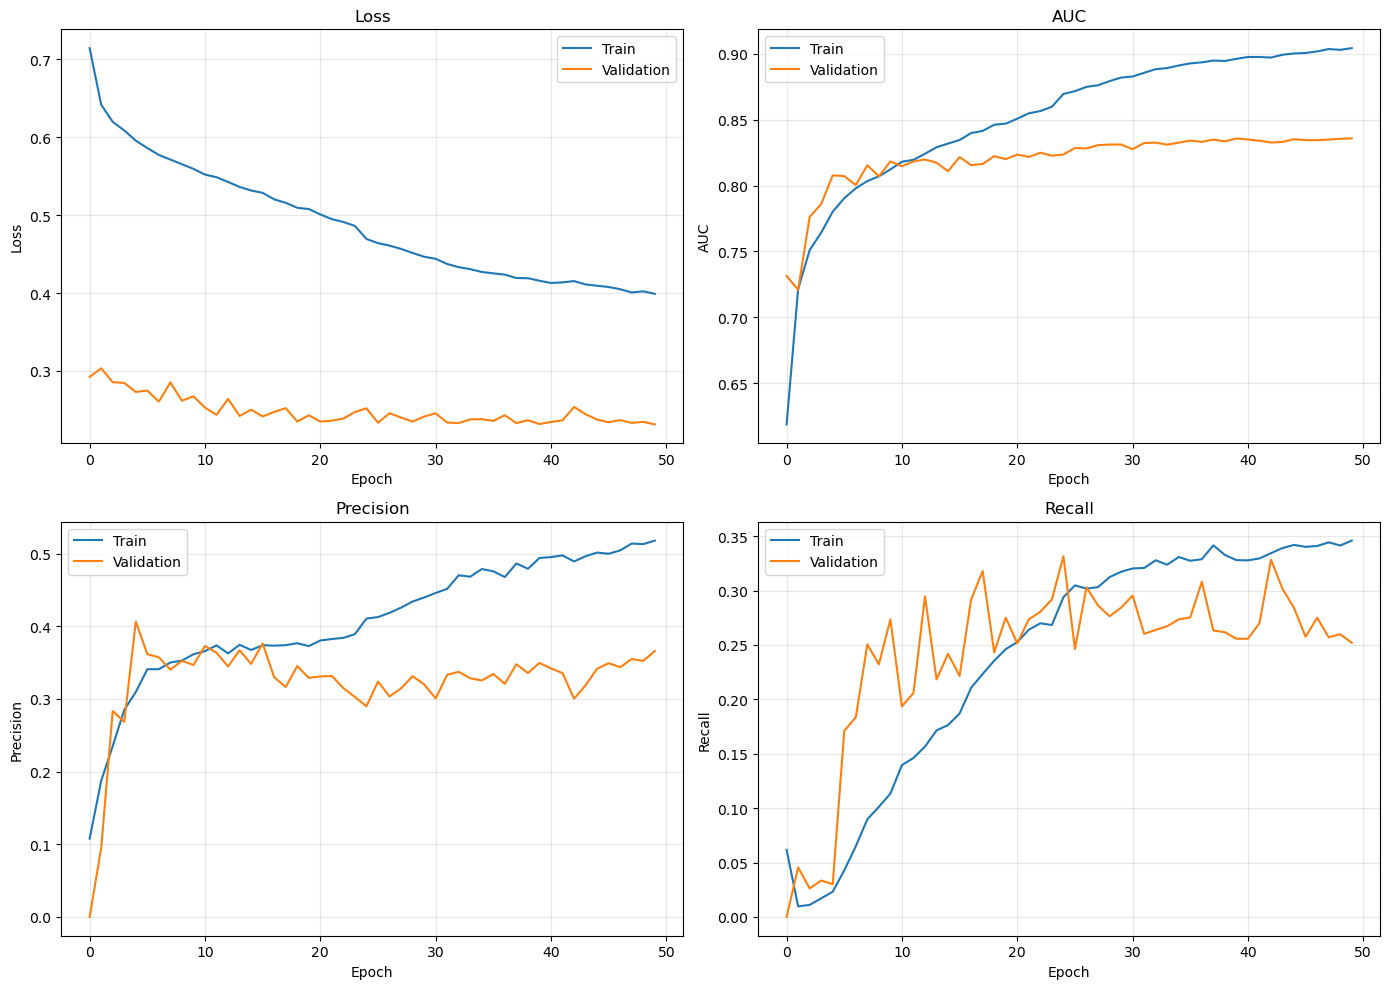

✓ Training history saved to ../output/crnn/run01_baseline/crnn_training_history.png


In [12]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train')
axes[0, 0].plot(history.history['val_loss'], label='Validation')
axes[0, 0].set_title('Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# AUC
axes[0, 1].plot(history.history['auc'], label='Train')
axes[0, 1].plot(history.history['val_auc'], label='Validation')
axes[0, 1].set_title('AUC')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train')
axes[1, 0].plot(history.history['val_precision'], label='Validation')
axes[1, 0].set_title('Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train')
axes[1, 1].plot(history.history['val_recall'], label='Validation')
axes[1, 1].set_title('Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/crnn_training_history.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Training history saved to {OUTPUT_DIR}/crnn_training_history.png")

## 13. Evaluate Model

In [13]:
print("\n" + "="*80)
print("EVALUATION ON VALIDATION SET")
print("="*80)

# Get predictions
y_pred_proba = model.predict(X_val, batch_size=BATCH_SIZE)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate metrics per label
results = {}

print(f"\n{'Label':<30} {'F1':<12} {'AUC':<12}")
print("-" * 54)

for i, label in enumerate(label_cols):
    f1 = f1_score(y_val[:, i], y_pred[:, i])
    auc = roc_auc_score(y_val[:, i], y_pred_proba[:, i])
    
    results[label] = {'f1': f1, 'auc': auc}
    print(f"{label:<30} {f1:<12.4f} {auc:<12.4f}")

# Macro averages
macro_f1 = np.mean([r['f1'] for r in results.values()])
macro_auc = np.mean([r['auc'] for r in results.values()])

print(f"\n{'Macro Average':<30} {macro_f1:<12.4f} {macro_auc:<12.4f}")

# Multi-label metrics
hamming = hamming_loss(y_val, y_pred)
subset_acc = np.mean(np.all(y_pred == y_val, axis=1))

print(f"\nMulti-label metrics:")
print(f"  Hamming Loss:     {hamming:.4f}")
print(f"  Subset Accuracy:  {subset_acc:.4f}")

# Per-label classification reports
for i, label in enumerate(label_cols):
    print(f"\n{'='*80}")
    print(f"Classification Report: {label}")
    print("="*80)
    print(classification_report(
        y_val[:, i],
        y_pred[:, i],
        target_names=['Negative', 'Positive'],
        digits=4
    ))


EVALUATION ON VALIDATION SET
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step

Label                          F1           AUC         
------------------------------------------------------
S-glutathionylation            0.1805       0.8081      
S-nitrosylation                0.3172       0.8078      
S-palmitoylation               0.3751       0.8324      

Macro Average                  0.2909       0.8161      

Multi-label metrics:
  Hamming Loss:     0.0849
  Subset Accuracy:  0.8042

Classification Report: S-glutathionylation
              precision    recall  f1-score   support

    Negative     0.9525    0.9776    0.9649     16849
    Positive     0.2588    0.1385    0.1805       953

    accuracy                         0.9326     17802
   macro avg     0.6057    0.5580    0.5727     17802
weighted avg     0.9154    0.9326    0.9229     17802


Classification Report: S-nitrosylation
              precision    recall  f1-score   support

    Negative     0.8994    0.9467    0.9224 

## 14. Save Model and Predictions

In [14]:
print("\nSaving outputs...")

# Save final model
model.save(f"{OUTPUT_DIR}/crnn_model_final.h5")
print(f"✓ Final model saved to {OUTPUT_DIR}/crnn_model_final.h5")

# Save validation predictions (for ensemble)
val_pred_df = pd.DataFrame({
    'ID': val_df['ID'],
    'crnn_glut_proba': y_pred_proba[:, 0],
    'crnn_nitro_proba': y_pred_proba[:, 1],
    'crnn_palm_proba': y_pred_proba[:, 2]
})
val_pred_df.to_csv(f"{OUTPUT_DIR}/crnn_val_predictions.csv", index=False)
print(f"✓ Validation predictions saved to {OUTPUT_DIR}/crnn_val_predictions.csv")

# Save results
results_df = pd.DataFrame(results).T
results_df.to_csv(f"{OUTPUT_DIR}/crnn_results.csv")
print(f"✓ Results saved to {OUTPUT_DIR}/crnn_results.csv")

print("\n" + "="*80)
print("✓ CRNN TRAINING COMPLETE!")
print("="*80)
print(f"\nFinal Performance:")
print(f"  Macro F1:  {macro_f1:.4f}")
print(f"  Macro AUC: {macro_auc:.4f}")
print(f"\nAll outputs saved to: {OUTPUT_DIR}/")
print("="*80)


Saving outputs...
✓ Final model saved to ../output/crnn/run01_baseline/crnn_model_final.h5
✓ Validation predictions saved to ../output/crnn/run01_baseline/crnn_val_predictions.csv
✓ Results saved to ../output/crnn/run01_baseline/crnn_results.csv

✓ CRNN TRAINING COMPLETE!

Final Performance:
  Macro F1:  0.2909
  Macro AUC: 0.8161

All outputs saved to: ../output/crnn/run01_baseline/
